In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

In [4]:
df_sales = pd.read_csv("FACT_SALES.csv")
df_products = pd.read_excel("DIM_PRODUCT.xlsx")
df_segment = pd.read_excel("DIM_SEGMENT.xlsx")
df_category = pd.read_csv("DIM_CATEGORY.csv")

In [6]:
# Separar semana y año
df_sales[['WEEK_NUM', 'YEAR']] = df_sales['WEEK'].str.split('-', expand=True)
df_sales['WEEK_NUM'] = df_sales['WEEK_NUM'].astype(int)
df_sales['YEAR'] = df_sales['YEAR'].astype(int)

# Convertir año de 2 dígitos a 4 dígitos
df_sales['YEAR'] = df_sales['YEAR'].apply(lambda x: 2000 + x if x < 100 else x)

# Crear fecha base: 1 de enero del año
df_sales['DATE'] = pd.to_datetime(df_sales['YEAR'].astype(str) + '-01-01')

# Sumar semanas (WEEK_NUM - 1) * 7 días
df_sales['DATE'] = df_sales['DATE'] + pd.to_timedelta((df_sales['WEEK_NUM'] - 1) * 7, unit='D')

df_sales[['WEEK', 'YEAR', 'WEEK_NUM', 'DATE']].head()
df_sales.head()

,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION,WEEK_NUM,YEAR,DATE
0,34-22,7501058792808BP2,0.006,0.139,1.000,TOTAL AUTOS AREA 5,34,2022,2022-08-20
1,34-22,7501058715883,0.487,116.519,2.916,TOTAL AUTOS AREA 5,34,2022,2022-08-20
2,34-22,7702626213774,1.391,68.453,5.171,TOTAL AUTOS AREA 5,34,2022,2022-08-20
3,34-22,7501058716422,0.022,1.481,1.833,TOTAL AUTOS AREA 5,34,2022,2022-08-20
4,34-22,7501058784353,2.037,182.839,5.375,TOTAL AUTOS AREA 5,34,2022,2022-08-20


In [9]:
# Merge 1: Producto + Segmento
df_full = df_products.merge(
    df_segment,
    how="left",
    left_on=["CATEGORY", "ATTR1", "ATTR2", "ATTR3", "FORMAT"],
    right_on=["CATEGORY", "ATTR1", "ATTR2", "ATTR3", "FORMAT"]
)

In [10]:
# Merge 2: Agregar ventas
df_full = df_full.merge(
    df_sales,
    left_on="ITEM", 
    right_on="ITEM_CODE", 
    how="left"
)

df_full.head()

,MANUFACTURER,BRAND,ITEM,ITEM_DESCRIPTION,CATEGORY,FORMAT,ATTR1,ATTR2,ATTR3,SEGMENT,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION,WEEK_NUM,YEAR,DATE
0,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,BLEACH,45-22,0000075000592,0.034,0.142,8.500,TOTAL AUTOS SCANNING MEXICO,45.0,2022.0,2022-11-05
1,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,BLEACH,48-22,0000075000592,0.002,0.009,1.000,TOTAL AUTOS SCANNING MEXICO,48.0,2022.0,2022-11-26
2,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,BLEACH,03-22,0000075000592,0.432,1.956,14.400,TOTAL AUTOS SCANNING MEXICO,3.0,2022.0,2022-01-15
3,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,BLEACH,05-22,0000075000592,0.233,0.779,11.095,TOTAL AUTOS SCANNING MEXICO,5.0,2022.0,2022-01-29
4,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,BLEACH,09-22,0000075000592,0.055,0.251,5.500,TOTAL AUTOS SCANNING MEXICO,9.0,2022.0,2022-02-26


## 3. Análisis Exploratorio de Datos (EDA)

### 3.1 Distribuci{on de Ventas}

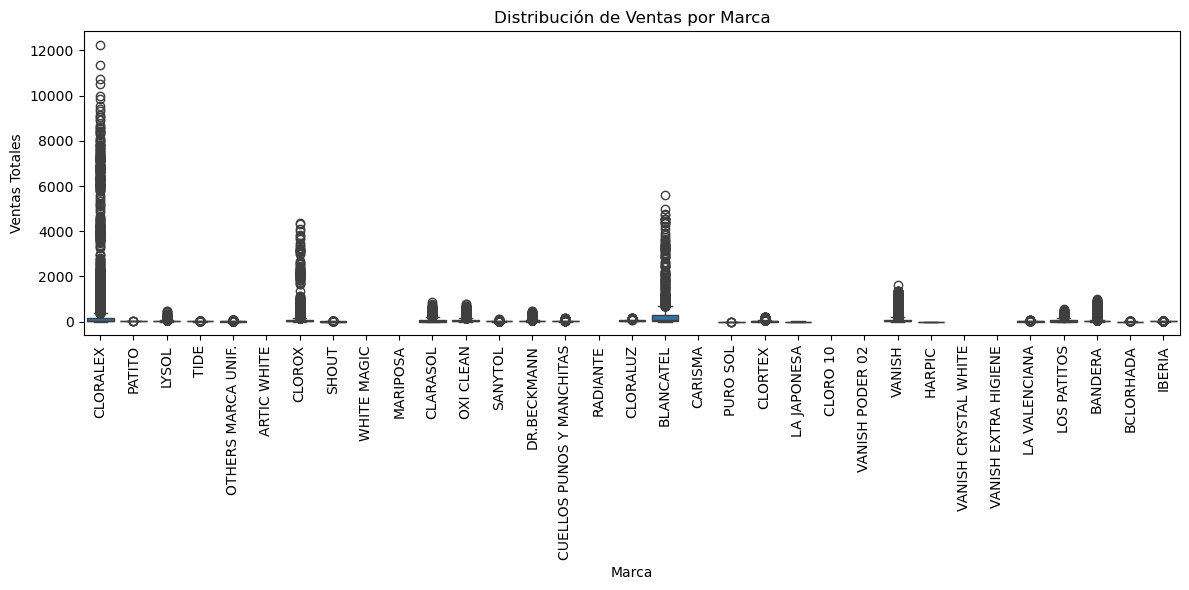

In [11]:
plt.figure(figsize=(12,6))
ax = sns.boxplot(data=df_full, x="BRAND", y="TOTAL_VALUE_SALES")

ax.set_title("Distribución de Ventas por Marca")
ax.set_xlabel("Marca")
ax.set_ylabel("Ventas Totales")

ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.tight_layout()
plt.show()



In [12]:
df_full.columns

Index(['MANUFACTURER', 'BRAND', 'ITEM', 'ITEM_DESCRIPTION', 'CATEGORY',
       'FORMAT', 'ATTR1', 'ATTR2', 'ATTR3', 'SEGMENT', 'WEEK', 'ITEM_CODE',
       'TOTAL_UNIT_SALES', 'TOTAL_VALUE_SALES', 'TOTAL_UNIT_AVG_WEEKLY_SALES',
       'REGION', 'WEEK_NUM', 'YEAR', 'DATE'],
      dtype='str')

In [13]:
df_full.head()

,MANUFACTURER,BRAND,ITEM,ITEM_DESCRIPTION,CATEGORY,FORMAT,ATTR1,ATTR2,ATTR3,SEGMENT,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION,WEEK_NUM,YEAR,DATE
0,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,BLEACH,45-22,0000075000592,0.034,0.142,8.500,TOTAL AUTOS SCANNING MEXICO,45.0,2022.0,2022-11-05
1,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,BLEACH,48-22,0000075000592,0.002,0.009,1.000,TOTAL AUTOS SCANNING MEXICO,48.0,2022.0,2022-11-26
2,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,BLEACH,03-22,0000075000592,0.432,1.956,14.400,TOTAL AUTOS SCANNING MEXICO,3.0,2022.0,2022-01-15
3,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,BLEACH,05-22,0000075000592,0.233,0.779,11.095,TOTAL AUTOS SCANNING MEXICO,5.0,2022.0,2022-01-29
4,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,BLEACH,09-22,0000075000592,0.055,0.251,5.500,TOTAL AUTOS SCANNING MEXICO,9.0,2022.0,2022-02-26


### 3.2 Tendencias Temporales

<Axes: xlabel='DATE'>

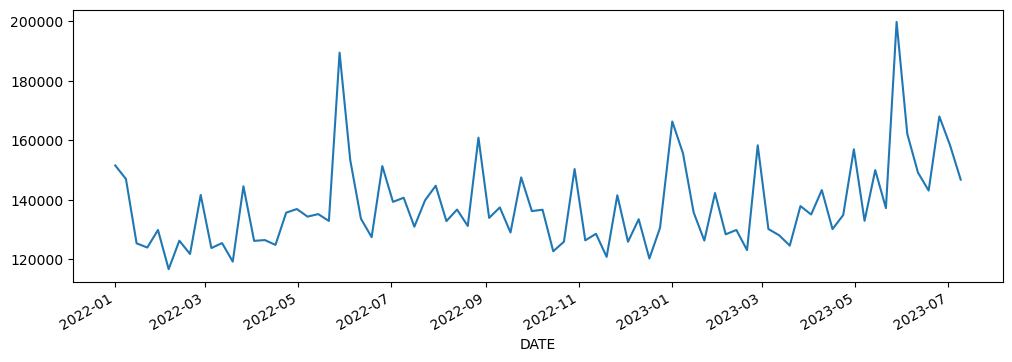

In [14]:
df_full.groupby("DATE")["TOTAL_VALUE_SALES"].sum().plot(figsize=(12,4))


### 3.3 Outliers

<Axes: xlabel='TOTAL_UNIT_SALES', ylabel='TOTAL_VALUE_SALES'>

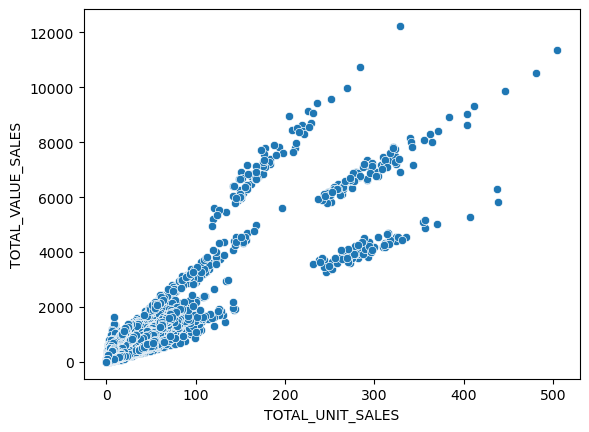

In [15]:
sns.scatterplot(data=df_full, x="TOTAL_UNIT_SALES", y="TOTAL_VALUE_SALES")


## 4. Segmentación de Productos o Regiones con Clustering

### 4.1 Aplicación de Clustering con K-Means:

In [16]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 1. Selección de variables
X = df_full[["TOTAL_VALUE_SALES", "TOTAL_UNIT_SALES"]]

# 2. Imputación
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)

# 3. Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# 4. PCA para visualización
pca = PCA(n_components=2)
pca_components = pca.fit_transform(X_scaled)

df_cluster_clean = df_full.copy()
df_cluster_clean["PC1"] = pca_components[:,0]
df_cluster_clean["PC2"] = pca_components[:,1]

# 5. K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
df_cluster_clean["Cluster"] = kmeans.fit_predict(X_scaled)



### 4.2 Método del codo

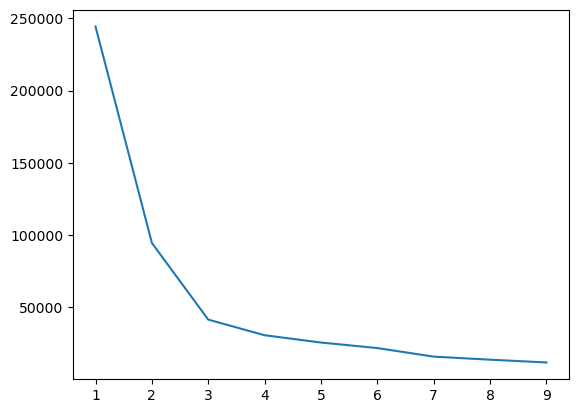

In [17]:
# Método del codo
inertia = []
for k in range(1,10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
plt.plot(range(1,10), inertia)
plt.show()

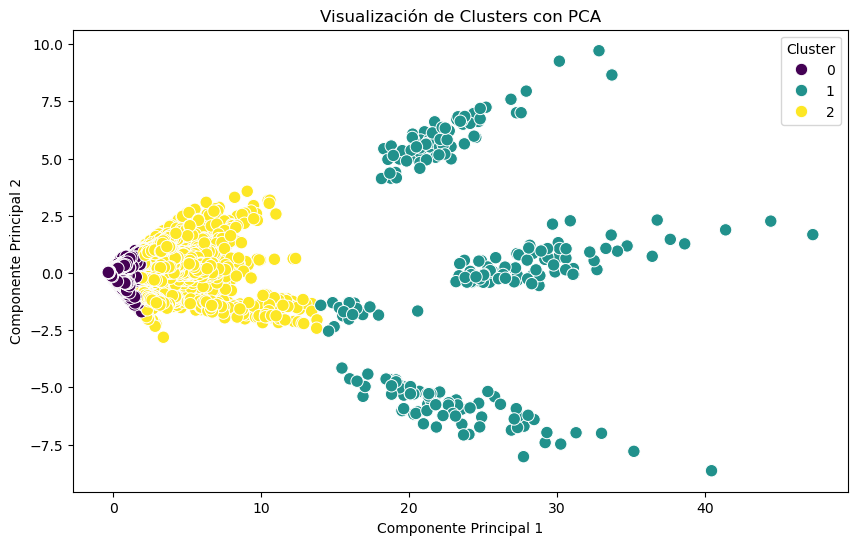

In [18]:
plt.figure(figsize=(10,6))

ax = sns.scatterplot(
    data=df_cluster_clean,   
    x="PC1",                 
    y="PC2",                 
    hue="Cluster",           
    palette="viridis",
    s=80
)

ax.set_title("Visualización de Clusters con PCA")
ax.set_xlabel("Componente Principal 1")
ax.set_ylabel("Componente Principal 2")
plt.legend(title="Cluster")
plt.show()


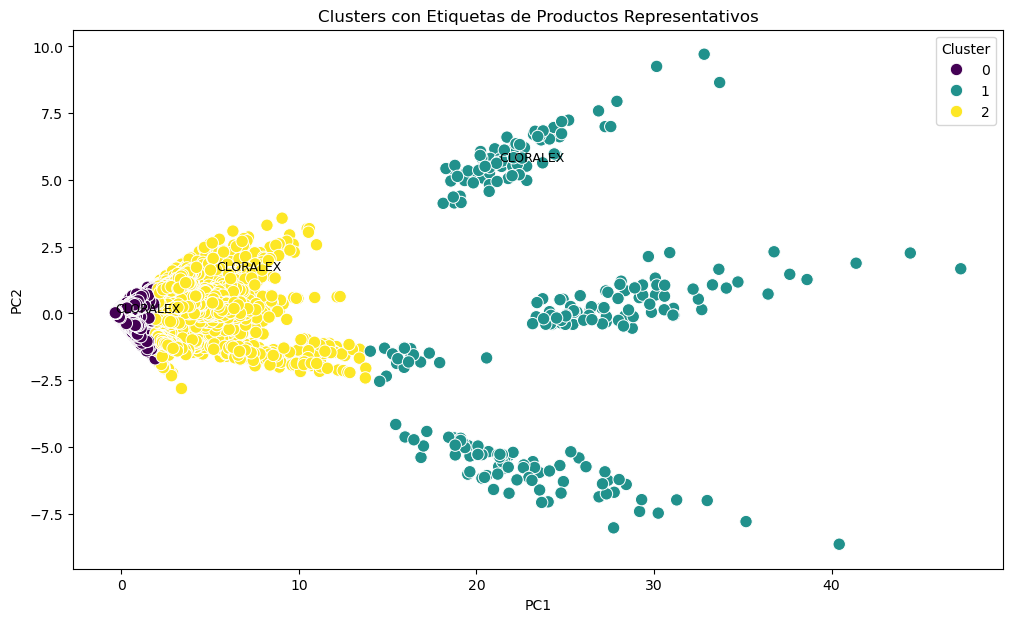

In [19]:
plt.figure(figsize=(12,7))

ax = sns.scatterplot(
    data=df_cluster_clean,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="viridis",
    s=80
)

# Etiquetar un producto por cluster
for c in df_cluster_clean["Cluster"].unique():
    sample = df_cluster_clean[df_cluster_clean["Cluster"] == c].iloc[0]
    plt.text(
        sample["PC1"] + 0.02,
        sample["PC2"] + 0.02,
        sample["BRAND"], 
        fontsize=9
    )

ax.set_title("Clusters con Etiquetas de Productos Representativos")
plt.show()



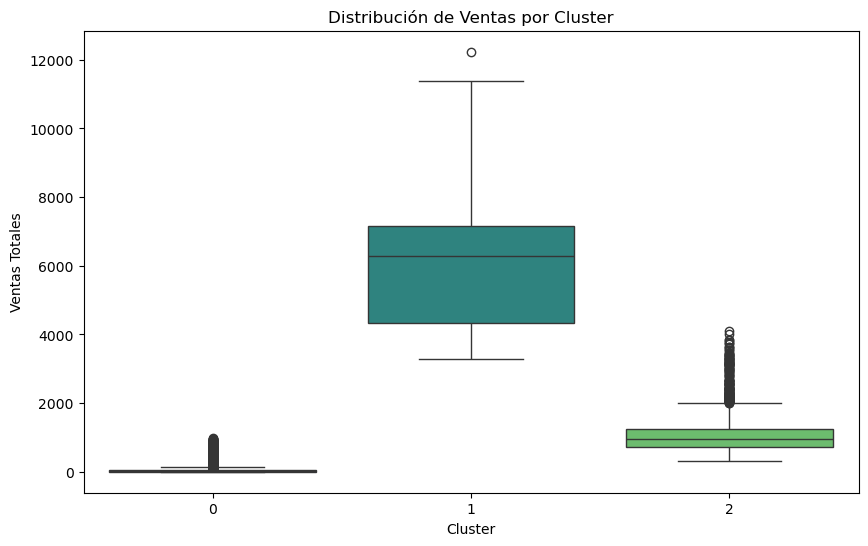

In [20]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df_cluster_clean,
    x="Cluster",
    y="TOTAL_VALUE_SALES",
    palette="viridis"
)

plt.title("Distribución de Ventas por Cluster")
plt.xlabel("Cluster")
plt.ylabel("Ventas Totales")
plt.show()


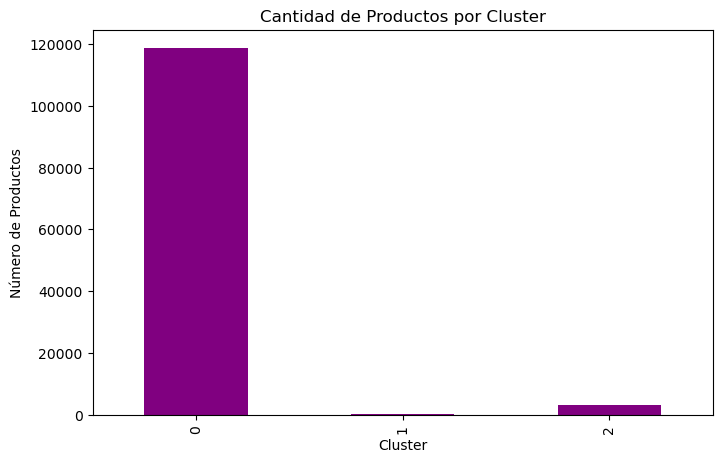

In [21]:
plt.figure(figsize=(8,5))
df_cluster_clean["Cluster"].value_counts().sort_index().plot(kind="bar", color="purple")

plt.title("Cantidad de Productos por Cluster")
plt.xlabel("Cluster")
plt.ylabel("Número de Productos")
plt.show()


In [ ]:
silhouette_scores = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"Clusters: {k}, Silhouette: {score:.4f}")


Clusters: 2, Silhouette: 0.9772
Clusters: 3, Silhouette: 0.9124
Clusters: 4, Silhouette: 0.8471
Clusters: 5, Silhouette: 0.8425
Clusters: 6, Silhouette: 0.8390


In [ ]:
plt.figure(figsize=(10,6))
plt.plot(K, silhouette_scores, marker='o', color='purple')
plt.title("Coeficiente de Silhouette para Selección de K")
plt.xlabel("Número de Clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()
